#### Import Libraries

In [3]:
import pandas as pd
from platform import python_version
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

#### Import Data

In [6]:
df_audusd = pd.read_pickle(r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules\fx_pair_1_5m.bz2")
df_eurusd = pd.read_pickle(r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules\fx_pair_2_5m.bz2")

print(df_audusd.shape)
print(df_eurusd.shape)

print(df_audusd.head(5))
print(df_eurusd.head(5))

(225385, 5)
(225385, 5)
                     open  high   low  close   volume
2018-01-01 00:00:00  0.78  0.78  0.78   0.78   2000.0
2018-01-01 00:05:00  0.78  0.78  0.78   0.78  10000.0
2018-01-01 00:10:00  0.78  0.78  0.78   0.78  10000.0
2018-01-01 00:15:00  0.78  0.78  0.78   0.78  10000.0
2018-01-01 00:20:00  0.78  0.78  0.78   0.78  10000.0
                      open   high    low  close   volume
2018-01-01 00:00:00  1.258  1.258  1.255  1.255   2000.0
2018-01-01 00:05:00  1.258  1.258  1.255  1.255  10000.0
2018-01-01 00:10:00  1.258  1.258  1.255  1.255  10000.0
2018-01-01 00:15:00  1.258  1.258  1.255  1.255  10000.0
2018-01-01 00:20:00  1.258  1.258  1.255  1.255  10000.0


#### Resample to 4hr intervals

In [7]:
# create resampling function
def resample_ohlcv(df, freq='4h'):
    return df.resample(freq).agg(
        {"open":"first",
         "high":"max",
         "low":"min",
         "close":"last",
         "volume":"sum"
        }
    ).dropna()

df_4h_audusd = resample_ohlcv(df_audusd)
df_4h_eurusd = resample_ohlcv(df_eurusd)

print(df_4h_audusd.shape)
print(df_4h_eurusd.shape)

print(df_4h_audusd.head(5))
print(df_4h_eurusd.head(5))

(4861, 5)
(4861, 5)
                     open  high   low  close    volume
2018-01-01 00:00:00  0.78  0.78  0.78   0.78  472000.0
2018-01-01 04:00:00  0.78  0.78  0.78   0.78  480000.0
2018-01-01 08:00:00  0.78  0.78  0.78   0.78  480000.0
2018-01-01 12:00:00  0.78  0.78  0.78   0.78  480000.0
2018-01-01 16:00:00  0.78  0.78  0.78   0.78  480000.0
                      open   high    low  close    volume
2018-01-01 00:00:00  1.258  1.258  1.255  1.255  472000.0
2018-01-01 04:00:00  1.258  1.258  1.255  1.255  480000.0
2018-01-01 08:00:00  1.258  1.258  1.255  1.255  480000.0
2018-01-01 12:00:00  1.258  1.258  1.255  1.255  480000.0
2018-01-01 16:00:00  1.258  1.258  1.255  1.255  480000.0


#### Data Sanity Check

In [8]:
# create function to audit the data
def run_sanity_checks(df, pair_name="FX Pair", freq="5m", volume_threshold=5.0, price_outlier_threshold=3.0):
    """
    Run a suite of data sanity checks on a raw OHLCV DataFrame.

    Parameters
    ----------
    df                      : pd.DataFrame  - OHLCV DataFrame with DatetimeIndex
    pair_name               : str           - Label used in printed output
    freq                    : str           - Expected bar frequency e.g. "5min", "4h"
    volume_threshold        : float         - Z-score threshold to flag volume spikes
    price_outlier_threshold : float         - Z-score threshold to flag price outliers

    Returns
    -------
    report : dict - Summary of all check results
    """
    print(f"DATA SANITY CHECK: {pair_name}")
    print(f"{'-'*60}")

    report = {}

    # Basic Shape Check
    print(f"\n[1] BASIC INFO")
    print(f"    Shape          : {df.shape}")
    print(f"    Data range     : {df.index[0]} --> {df.index[-1]}")
    print(f"    Expected freq  : {freq}")
    report["shape"] = df.shape
    report["date_range"] = (df.index[0], df.index[-1])
    

    # Missing Values
    print(f"\n[2] MISSING VALUES")
    missing = df.isnull().sum()
    missing_pct = (missing/len(df))*100
    for col in df.columns:
        status = "OK" if missing[col] == 0 else "WARNING"
        print(f"    {col:<10}: {missing[col]:>6} missing ({missing_pct[col]:.3f}%) [{status}]")
    report["missing_values"] = missing.to_dict()


    # Duplicate timestamps
    print(f"\n[3] DUPLICATE TIMESTAMPS")
    dupes = df.index.duplicated().sum()
    status = "OK" if dupes == 0 else "WARNING -- drop or deduplicate before modelling"
    print(f"    Duplicate timestamps: {dupes}  [{status}]")
    report["duplicate_timestamps"] = int(dupes)    
    
    
    # Timestamp Gaps
    print(f"\n[4] TIMESTAMP GAPS")
    expected_index = pd.date_range(start=df.index[0], end=df.index[-1], freq=freq)
    missing_timestamps = expected_index.difference(df.index)
    print(f"    Expected bars  : {len(expected_index):>8,}")
    print(f"    Actual bars    : {len(df):>8,}")
    print(f"    Missing bars   : {len(missing_timestamps):>8,}")
    if len(missing_timestamps) > 0:
        print(f"    First gap at   : {missing_timestamps[0]}")
        print(f"    Last gap at    : {missing_timestamps[-1]}")
        print(f"    [NOTE] Gaps often correspond to weekends, holidays, or low-liquidity periods.")
    else:
        print(f"    [OK] No timestamp gaps detected.")
    report["missing_bars"] = len(missing_timestamps)


    # Zero Volume
    print(f"\n[5] ZERO / NEGATIVE VOLUME BARS")
    zero_vol = (df["volume"] <= 0).sum()
    pct = (zero_vol / len(df)) * 100
    status = "OK" if zero_vol == 0 else "WARNING"
    print(f"    Zero/negative volume bars: {zero_vol}  ({pct:.3f}%)  [{status}]")
    report["zero_volume_bars"] = int(zero_vol)


    # OHLC consistency
    print(f"\n[6] OHLC CONSISTENCY")
    checks = {
        "high >= low"   : (df["high"] >= df["low"]).all(),
        "high >= open"  : (df["high"] >= df["open"]).all(),
        "high >= close" : (df["high"] >= df["close"]).all(),
        "low  <= open"  : (df["low"]  <= df["open"]).all(),
        "low  <= close" : (df["low"]  <= df["close"]).all(),
    }
    for check, passed in checks.items():
        print(f"    {check:<20}: {'OK' if passed else 'FAILED -- inspect these rows'}")
    report["ohlc_consistency"] = checks


    # Price Outliers
    print(f"\n[7] PRICE OUTLIERS (close, Z-score > {price_outlier_threshold})")
    z_close = np.abs((df["close"] - df["close"].mean()) / df["close"].std())
    outliers = df[z_close > price_outlier_threshold]
    print(f"    Outlier bars   : {len(outliers)}")
    if len(outliers) > 0:
        print(f"    Min outlier    : {outliers['close'].min():.5f}")
        print(f"    Max outlier    : {outliers['close'].max():.5f}")
        print(f"    [NOTE] Review whether these coincide with macro events or are data errors.")
    else:
        print(f"    [OK] No price outliers detected at Z > {price_outlier_threshold}.")
    report["price_outliers"] = len(outliers)


    # Volume Spikes
    print(f"\n[8] VOLUME SPIKES (Z-score > {volume_threshold})")
    z_vol = np.abs((df["volume"] - df["volume"].mean()) / df["volume"].std())
    vol_spikes = df[z_vol > volume_threshold]
    print(f"    Volume spike bars: {len(vol_spikes)}")
    if len(vol_spikes) > 0:
        print(f"    Max volume bar : {vol_spikes['volume'].max():,.0f}")
        print(f"    [NOTE] Spikes may indicate news events -- worth keeping but worth knowing about.")
    report["volume_spikes"] = len(vol_spikes)


    # Flat price check
    print(f"\n[9] STALE PRICE RUNS (close unchanged >= 5 consecutive bars)")
    stale = (df["close"].diff() == 0)
    stale_runs = stale.groupby((stale != stale.shift()).cumsum()).sum()
    long_stale = (stale_runs >= 5).sum()
    print(f"    Stale runs >= 5 bars: {long_stale}")
    if long_stale > 0:
        print(f"    [WARNING] Could indicate illiquid periods or feed issues.")
    else:
        print(f"    [OK] No significant stale price runs detected.")
    report["stale_price_runs"] = int(long_stale)


    # Summary
    print(f"\n{'-'*60}")
    print(f"  SUMMARY: {pair_name}")
    print(f"\n{'-'*60}")
    warnings_found = (
        any(v > 0 for v in missing.values)
        or dupes > 0
        or zero_vol > 0
        or not all(checks.values())
        or len(outliers) > 0
        or long_stale > 0
    )
    if not warnings_found:
        print(f"  All checks passed. Data looks clean -- proceed with resampling.\n")
    else:
        print(f"  One or more checks flagged issues. Review warnings above before modelling.\n")

    return report

In [9]:
report_audusd = run_sanity_checks(df_4h_audusd, pair_name='AUD/USD', freq="4h")

DATA SANITY CHECK: AUD/USD
------------------------------------------------------------

[1] BASIC INFO
    Shape          : (4861, 5)
    Data range     : 2018-01-01 00:00:00 --> 2021-01-16 00:00:00
    Expected freq  : 4h

[2] MISSING VALUES
    open      :      0 missing (0.000%) [OK]
    high      :      0 missing (0.000%) [OK]
    low       :      0 missing (0.000%) [OK]
    close     :      0 missing (0.000%) [OK]
    volume    :      0 missing (0.000%) [OK]

[3] DUPLICATE TIMESTAMPS
    Duplicate timestamps: 0  [OK]

[4] TIMESTAMP GAPS
    Expected bars  :    6,667
    Actual bars    :    4,861
    Missing bars   :    1,806
    First gap at   : 2018-01-06 04:00:00
    Last gap at    : 2021-01-10 20:00:00
    [NOTE] Gaps often correspond to weekends, holidays, or low-liquidity periods.

[5] ZERO / NEGATIVE VOLUME BARS
    Zero/negative volume bars: 0  (0.000%)  [OK]

[6] OHLC CONSISTENCY
    high >= low         : FAILED -- inspect these rows
    high >= open        : FAILED -- in

In [10]:
report_eurusd = run_sanity_checks(df_4h_eurusd, pair_name='EUR/USD', freq="4h")

DATA SANITY CHECK: EUR/USD
------------------------------------------------------------

[1] BASIC INFO
    Shape          : (4861, 5)
    Data range     : 2018-01-01 00:00:00 --> 2021-01-16 00:00:00
    Expected freq  : 4h

[2] MISSING VALUES
    open      :      0 missing (0.000%) [OK]
    high      :      0 missing (0.000%) [OK]
    low       :      0 missing (0.000%) [OK]
    close     :      0 missing (0.000%) [OK]
    volume    :      0 missing (0.000%) [OK]

[3] DUPLICATE TIMESTAMPS
    Duplicate timestamps: 0  [OK]

[4] TIMESTAMP GAPS
    Expected bars  :    6,667
    Actual bars    :    4,861
    Missing bars   :    1,806
    First gap at   : 2018-01-06 04:00:00
    Last gap at    : 2021-01-10 20:00:00
    [NOTE] Gaps often correspond to weekends, holidays, or low-liquidity periods.

[5] ZERO / NEGATIVE VOLUME BARS
    Zero/negative volume bars: 0  (0.000%)  [OK]

[6] OHLC CONSISTENCY
    high >= low         : FAILED -- inspect these rows
    high >= open        : FAILED -- in

####  OHLC Consistency: Inspect and Fix

AUD/USD: 129 rows with OHLC violations
                      open   high    low  close
2018-03-26 00:00:00  0.770  0.773  0.771  0.772
2018-04-25 08:00:00  0.757  0.758  0.756  0.755
2018-05-19 00:00:00  0.750  0.750  0.751  0.750
2018-06-01 08:00:00  0.755  0.755  0.753  0.752
2018-06-04 00:00:00  0.756  0.761  0.757  0.761
2018-06-26 04:00:00  0.741  0.741  0.740  0.739
2018-08-03 16:00:00  0.740  0.740  0.740  0.739
2018-08-09 16:00:00  0.739  0.739  0.738  0.737
2018-08-11 00:00:00  0.729  0.730  0.730  0.729
2018-08-16 08:00:00  0.725  0.727  0.726  0.726

Magnitude of high-low violations (should be ~0 if floating point):
count    129.000000
mean       0.001132
std        0.002517
min       -0.002000
25%       -0.001000
50%        0.000000
75%        0.002000
max        0.012000
Name: hl_diff, dtype: float64


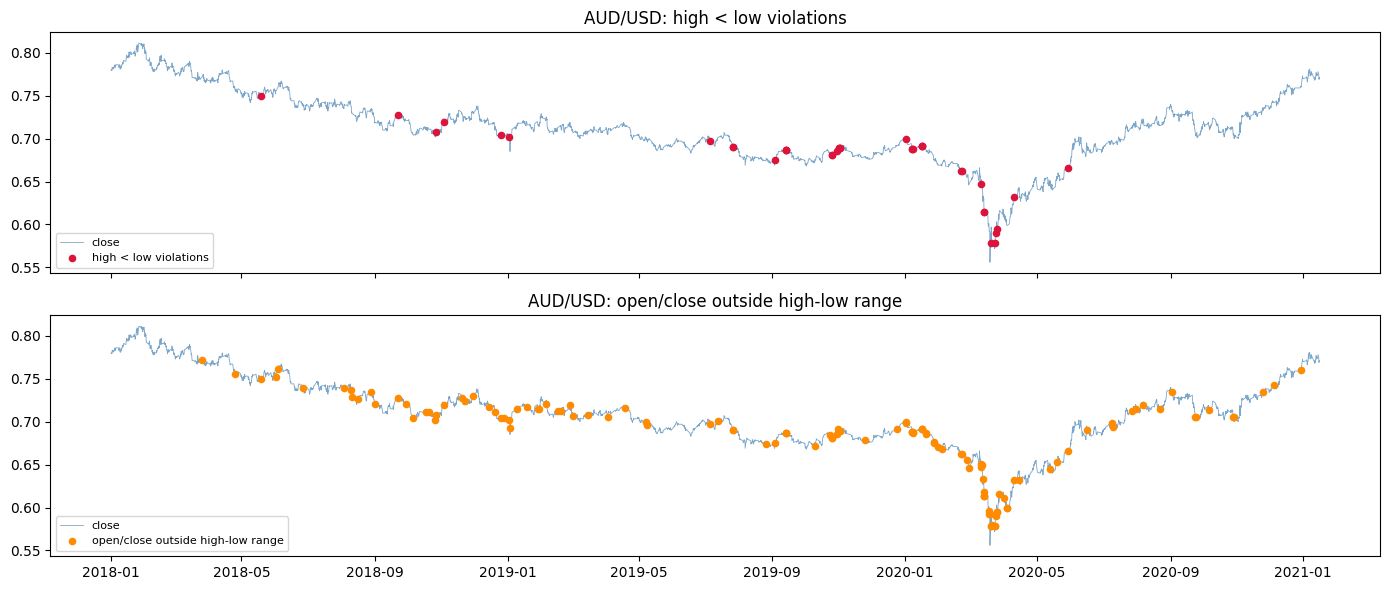

EUR/USD: 194 rows with OHLC violations
                      open   high    low  close
2018-03-26 12:00:00  1.288  1.291  1.287  1.286
2018-03-30 04:00:00  1.288  1.289  1.287  1.286
2018-03-31 00:00:00  1.289  1.289  1.290  1.289
2018-04-17 08:00:00  1.256  1.257  1.255  1.254
2018-05-09 08:00:00  1.296  1.295  1.290  1.290
2018-05-09 12:00:00  1.291  1.290  1.284  1.285
2018-05-10 04:00:00  1.283  1.284  1.278  1.277
2018-05-30 12:00:00  1.297  1.301  1.284  1.283
2018-06-06 08:00:00  1.295  1.295  1.290  1.289
2018-06-19 04:00:00  1.320  1.324  1.321  1.323

Magnitude of high-low violations (should be ~0 if floating point):
count    194.000000
mean       0.001665
std        0.003822
min       -0.002000
25%       -0.001000
50%        0.000000
75%        0.003000
max        0.032000
Name: hl_diff, dtype: float64


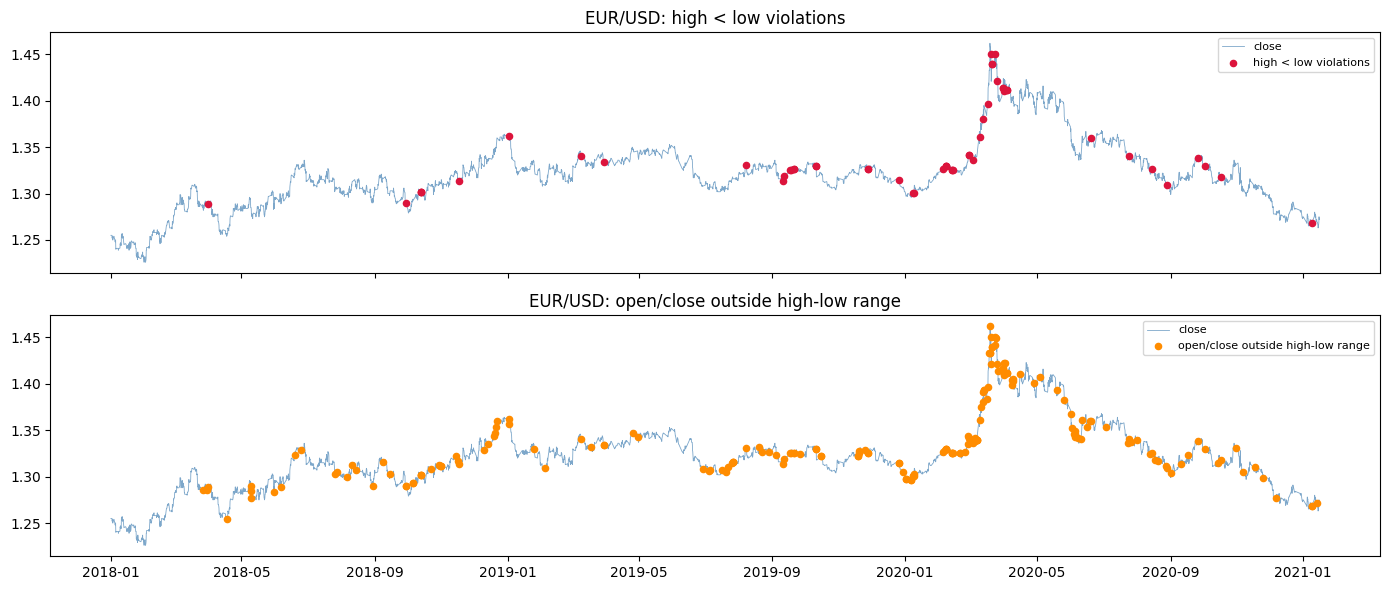

In [11]:
def investigate_ohlc_failures(df, pair_name="FX Pair"):
    """
    Identify rows where OHLC relationships are violated and visualise them.
    Most likely cause after resampling: floating point precision drift.
    """
    mask_hl  = df["high"] < df["low"]
    mask_ho  = df["high"] < df["open"]
    mask_lo  = df["low"]  > df["open"]
    mask_lc  = df["low"]  > df["close"]
    any_fail = mask_hl | mask_ho | mask_lo | mask_lc

    bad = df[any_fail].copy()
    print(f"{pair_name}: {len(bad)} rows with OHLC violations")
    print(bad[["open","high","low","close"]].head(10))

    # How large are the violations?
    bad["hl_diff"] = bad["high"] - bad["low"]
    bad["ho_diff"] = bad["high"] - bad["open"]
    bad["lo_diff"] = bad["low"]  - bad["open"]
    print(f"\nMagnitude of high-low violations (should be ~0 if floating point):")
    print(bad["hl_diff"].describe())

    # Plot: are violations clustered in time or random?
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    for ax, mask, label, color in zip(
        axes,
        [mask_hl, mask_lo | mask_ho | mask_lc],
        ["high < low violations", "open/close outside high-low range"],
        ["crimson", "darkorange"]
    ):
        ax.plot(df.index, df["close"], color="steelblue", linewidth=0.6, alpha=0.7, label="close")
        ax.scatter(df[mask].index, df[mask]["close"], color=color, s=20, zorder=5, label=label)
        ax.set_title(f"{pair_name}: {label}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return bad

bad_audusd = investigate_ohlc_failures(df_4h_audusd, "AUD/USD")
bad_eurusd = investigate_ohlc_failures(df_4h_eurusd, "EUR/USD")

In [12]:
def fix_ohlc(df):
    """
    Fix OHLC violations with two passes:

    Pass 1 -- floating point fix: if violation magnitude < 1e-8, it is a
    precision artefact from resampling. Snap the offending value.

    Pass 2 -- structural fix: enforce high = max(o,h,l,c) and
    low = min(o,h,l,c) for any remaining violations.
    """
    df = df.copy()

    # Pass 1: floating point snap
    fp_thresh = 1e-8
    fp_mask = (df["high"] - df["low"]).abs() < fp_thresh
    df.loc[fp_mask, "high"] = df.loc[fp_mask, ["open","high","low","close"]].max(axis=1)
    df.loc[fp_mask, "low"]  = df.loc[fp_mask, ["open","high","low","close"]].min(axis=1)

    # Pass 2: enforce for any remaining violations
    still_bad = (df["high"] < df["low"]) | (df["high"] < df["open"]) | \
                (df["low"]  > df["open"]) | (df["low"] > df["close"])
    df.loc[still_bad, "high"] = df.loc[still_bad, ["open","high","low","close"]].max(axis=1)
    df.loc[still_bad, "low"]  = df.loc[still_bad, ["open","high","low","close"]].min(axis=1)

    # Verify
    remaining = ((df["high"] < df["low"]) | (df["high"] < df["open"]) |
                 (df["low"] > df["open"])  | (df["low"] > df["close"])).sum()
    print(f"Remaining OHLC violations after fix: {remaining}")
    return df

df_4h_audusd = fix_ohlc(df_4h_audusd)
df_4h_eurusd = fix_ohlc(df_4h_eurusd)

Remaining OHLC violations after fix: 0
Remaining OHLC violations after fix: 0


#### Timestamp Gaps: Are They Just Weekends?

AUD/USD: gap breakdown by weekday
Sunday       882
Saturday     798
Friday        40
Monday        30
Tuesday       25
Wednesday     20
Thursday      11

93.0% of gaps fall on weekends
Weekday gaps (non-weekend): 126
DatetimeIndex(['2018-12-25 04:00:00', '2018-12-25 08:00:00',
               '2018-12-25 12:00:00', '2018-12-25 16:00:00',
               '2018-12-25 20:00:00', '2019-01-01 04:00:00',
               '2019-01-01 08:00:00', '2019-01-01 12:00:00',
               '2019-01-01 16:00:00', '2019-01-01 20:00:00',
               '2019-01-11 04:00:00', '2019-01-11 08:00:00',
               '2019-01-11 12:00:00', '2019-01-11 16:00:00',
               '2019-01-11 20:00:00', '2019-04-08 00:00:00',
               '2019-04-08 04:00:00', '2019-04-08 08:00:00',
               '2019-04-08 12:00:00', '2019-04-08 16:00:00'],
              dtype='datetime64[ns]', freq=None)


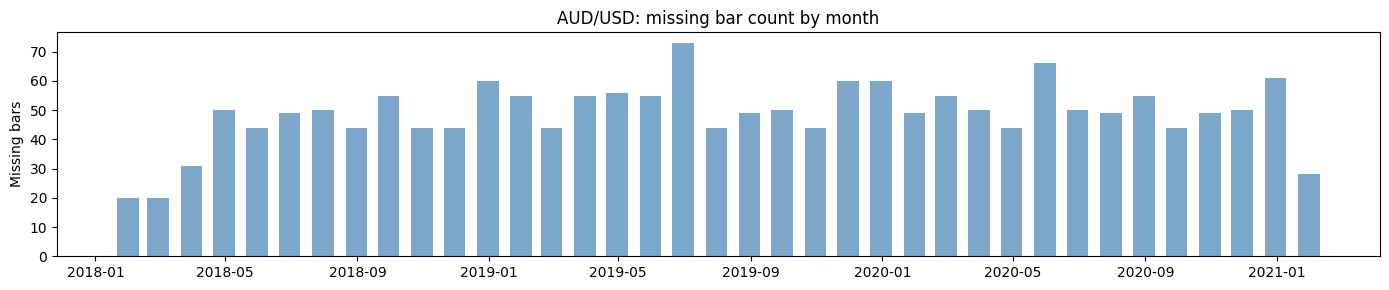

EUR/USD: gap breakdown by weekday
Sunday       882
Saturday     798
Friday        40
Monday        30
Tuesday       25
Wednesday     20
Thursday      11

93.0% of gaps fall on weekends
Weekday gaps (non-weekend): 126
DatetimeIndex(['2018-12-25 04:00:00', '2018-12-25 08:00:00',
               '2018-12-25 12:00:00', '2018-12-25 16:00:00',
               '2018-12-25 20:00:00', '2019-01-01 04:00:00',
               '2019-01-01 08:00:00', '2019-01-01 12:00:00',
               '2019-01-01 16:00:00', '2019-01-01 20:00:00',
               '2019-01-11 04:00:00', '2019-01-11 08:00:00',
               '2019-01-11 12:00:00', '2019-01-11 16:00:00',
               '2019-01-11 20:00:00', '2019-04-08 00:00:00',
               '2019-04-08 04:00:00', '2019-04-08 08:00:00',
               '2019-04-08 12:00:00', '2019-04-08 16:00:00'],
              dtype='datetime64[ns]', freq=None)


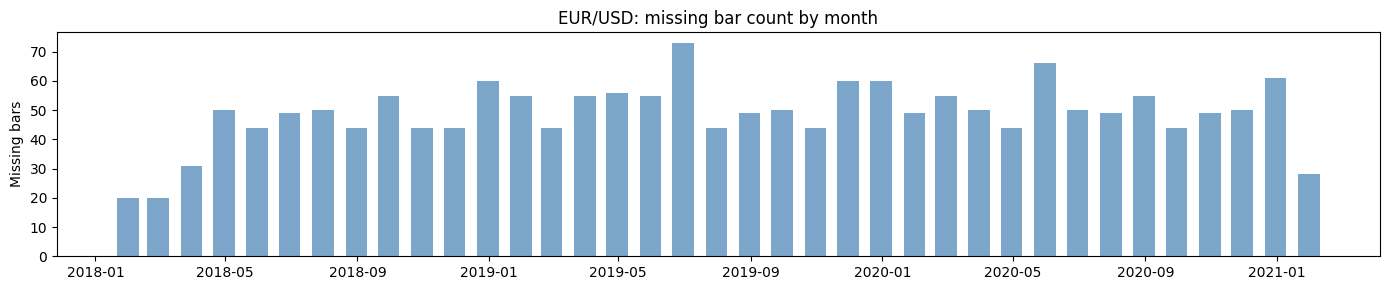

In [13]:
def investigate_gaps(df, pair_name="FX Pair", freq="4h"):
    """
    Characterise missing bars -- are they weekends, holidays, or something else?
    """
    expected = pd.date_range(start=df.index[0], end=df.index[-1], freq=freq)
    gaps = expected.difference(df.index).to_series()

    # What day of the week do gaps fall on?
    gap_dow = gaps.index.day_name().value_counts()
    print(f"{pair_name}: gap breakdown by weekday")
    print(gap_dow.to_string())

    weekend_pct = gap_dow.get("Saturday", 0) + gap_dow.get("Sunday", 0)
    weekend_pct = weekend_pct / len(gaps) * 100
    print(f"\n{weekend_pct:.1f}% of gaps fall on weekends")

    # Are there any weekday gaps (potential data issues)?
    weekday_gaps = gaps[~gaps.index.day_name().isin(["Saturday", "Sunday"])]
    print(f"Weekday gaps (non-weekend): {len(weekday_gaps)}")
    if len(weekday_gaps) > 0:
        print(weekday_gaps.index[:20])

    # Plot gap density over time
    fig, ax = plt.subplots(figsize=(14, 3))
    monthly_gaps = gaps.resample("ME").count()
    ax.bar(monthly_gaps.index, monthly_gaps.values, width=20, color="steelblue", alpha=0.7)
    ax.set_title(f"{pair_name}: missing bar count by month")
    ax.set_ylabel("Missing bars")
    plt.tight_layout()
    plt.show()

investigate_gaps(df_4h_audusd, "AUD/USD")
investigate_gaps(df_4h_eurusd, "EUR/USD")

#### Price Outliers: Macro Event or Data Error?

AUD/USD: 21 outliers, 2 look like single-bar spikes


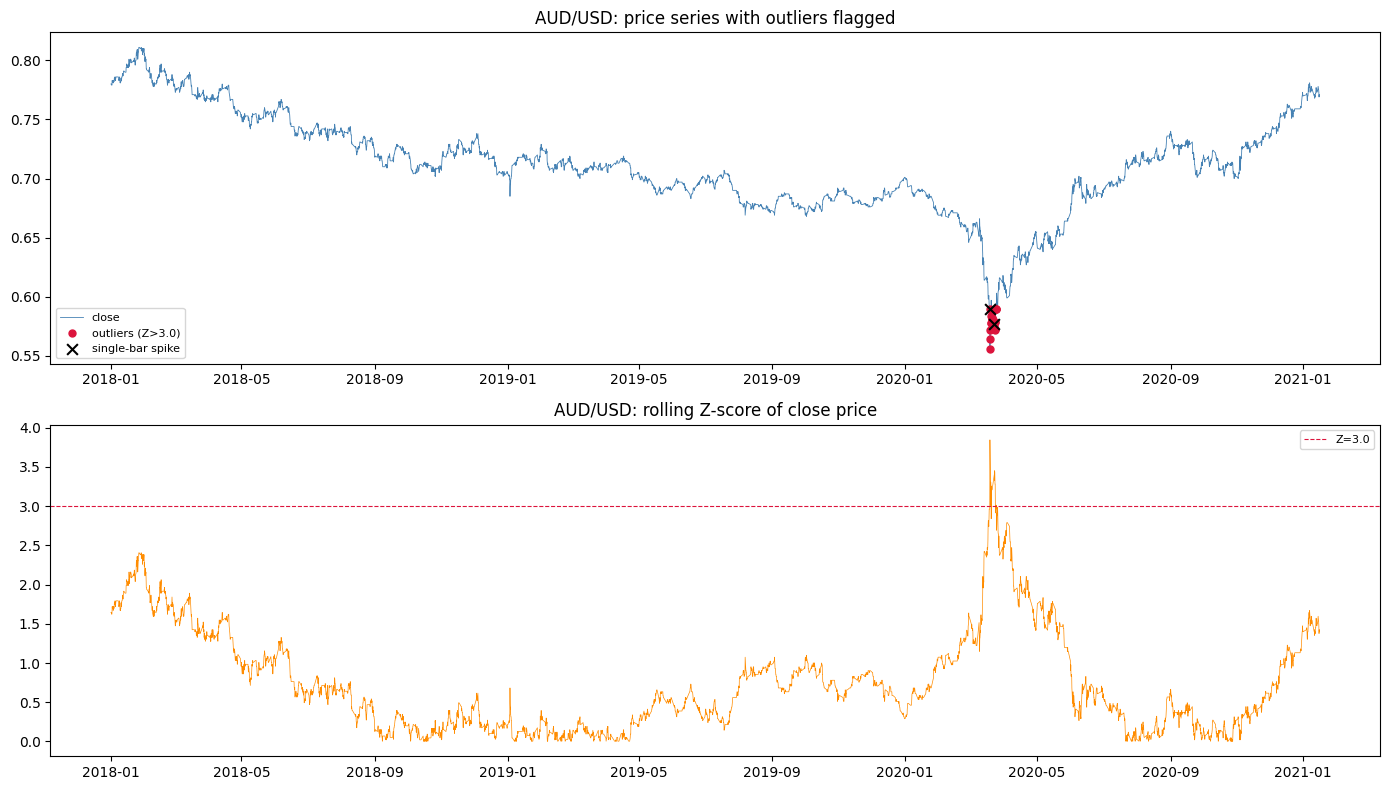

EUR/USD: 31 outliers, 4 look like single-bar spikes


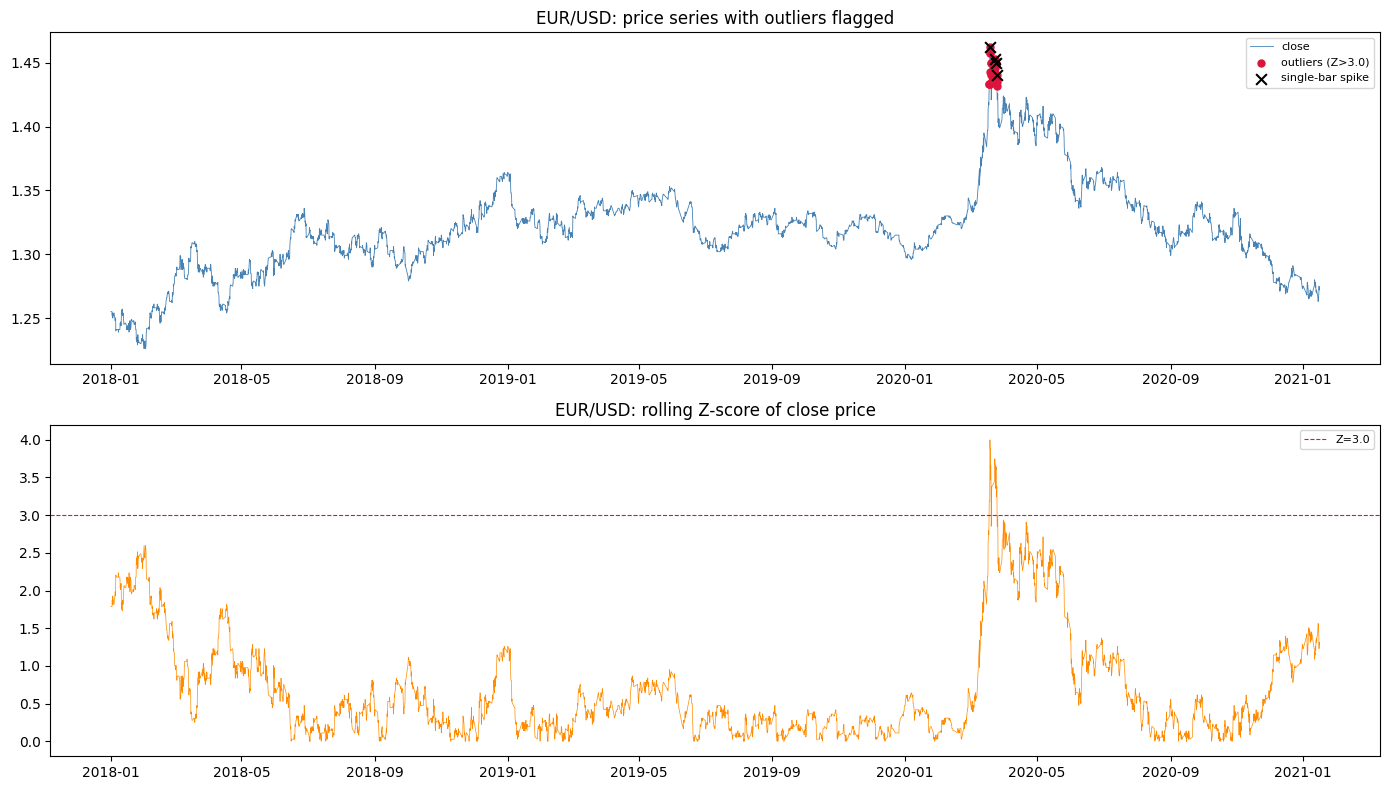

In [14]:
def investigate_outliers(df, pair_name="FX Pair", z_thresh=3.0):
    """
    Plot outlier bars in context. Genuine macro moves cluster around
    known events; data errors tend to be isolated single-bar spikes
    that reverse immediately.
    """
    z = np.abs((df["close"] - df["close"].mean()) / df["close"].std())
    outlier_mask = z > z_thresh
    outliers = df[outlier_mask]

    # Check for immediate reversal (single-bar spike signature of bad data)
    close = df["close"]
    single_spike = (
        (close.shift(1).abs() < close.abs()) &
        (close.shift(-1).abs() < close.abs())
    )
    bad_data_candidates = outliers[single_spike[outlier_mask]]
    print(f"{pair_name}: {len(outliers)} outliers, "
          f"{len(bad_data_candidates)} look like single-bar spikes")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Full series with outliers highlighted
    axes[0].plot(df.index, df["close"], color="steelblue", linewidth=0.6, label="close")
    axes[0].scatter(outliers.index, outliers["close"],
                    color="crimson", s=25, zorder=5, label=f"outliers (Z>{z_thresh})")
    axes[0].scatter(bad_data_candidates.index, bad_data_candidates["close"],
                    color="black", marker="x", s=60, zorder=6, label="single-bar spike")
    axes[0].set_title(f"{pair_name}: price series with outliers flagged")
    axes[0].legend(fontsize=8)

    # Z-score over time
    axes[1].plot(df.index, z, color="darkorange", linewidth=0.5)
    axes[1].axhline(z_thresh, color="crimson", linestyle="--", linewidth=0.8, label=f"Z={z_thresh}")
    axes[1].set_title(f"{pair_name}: rolling Z-score of close price")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return outliers, bad_data_candidates

out_aud, spikes_aud = investigate_outliers(df_4h_audusd, "AUD/USD")
out_eur, spikes_eur = investigate_outliers(df_4h_eurusd, "EUR/USD")

#### Stale Price Runs: Illiquidity or Feed Freeze?

AUD/USD: 46 stale runs >= 5 bars
Longest run: 10 bars


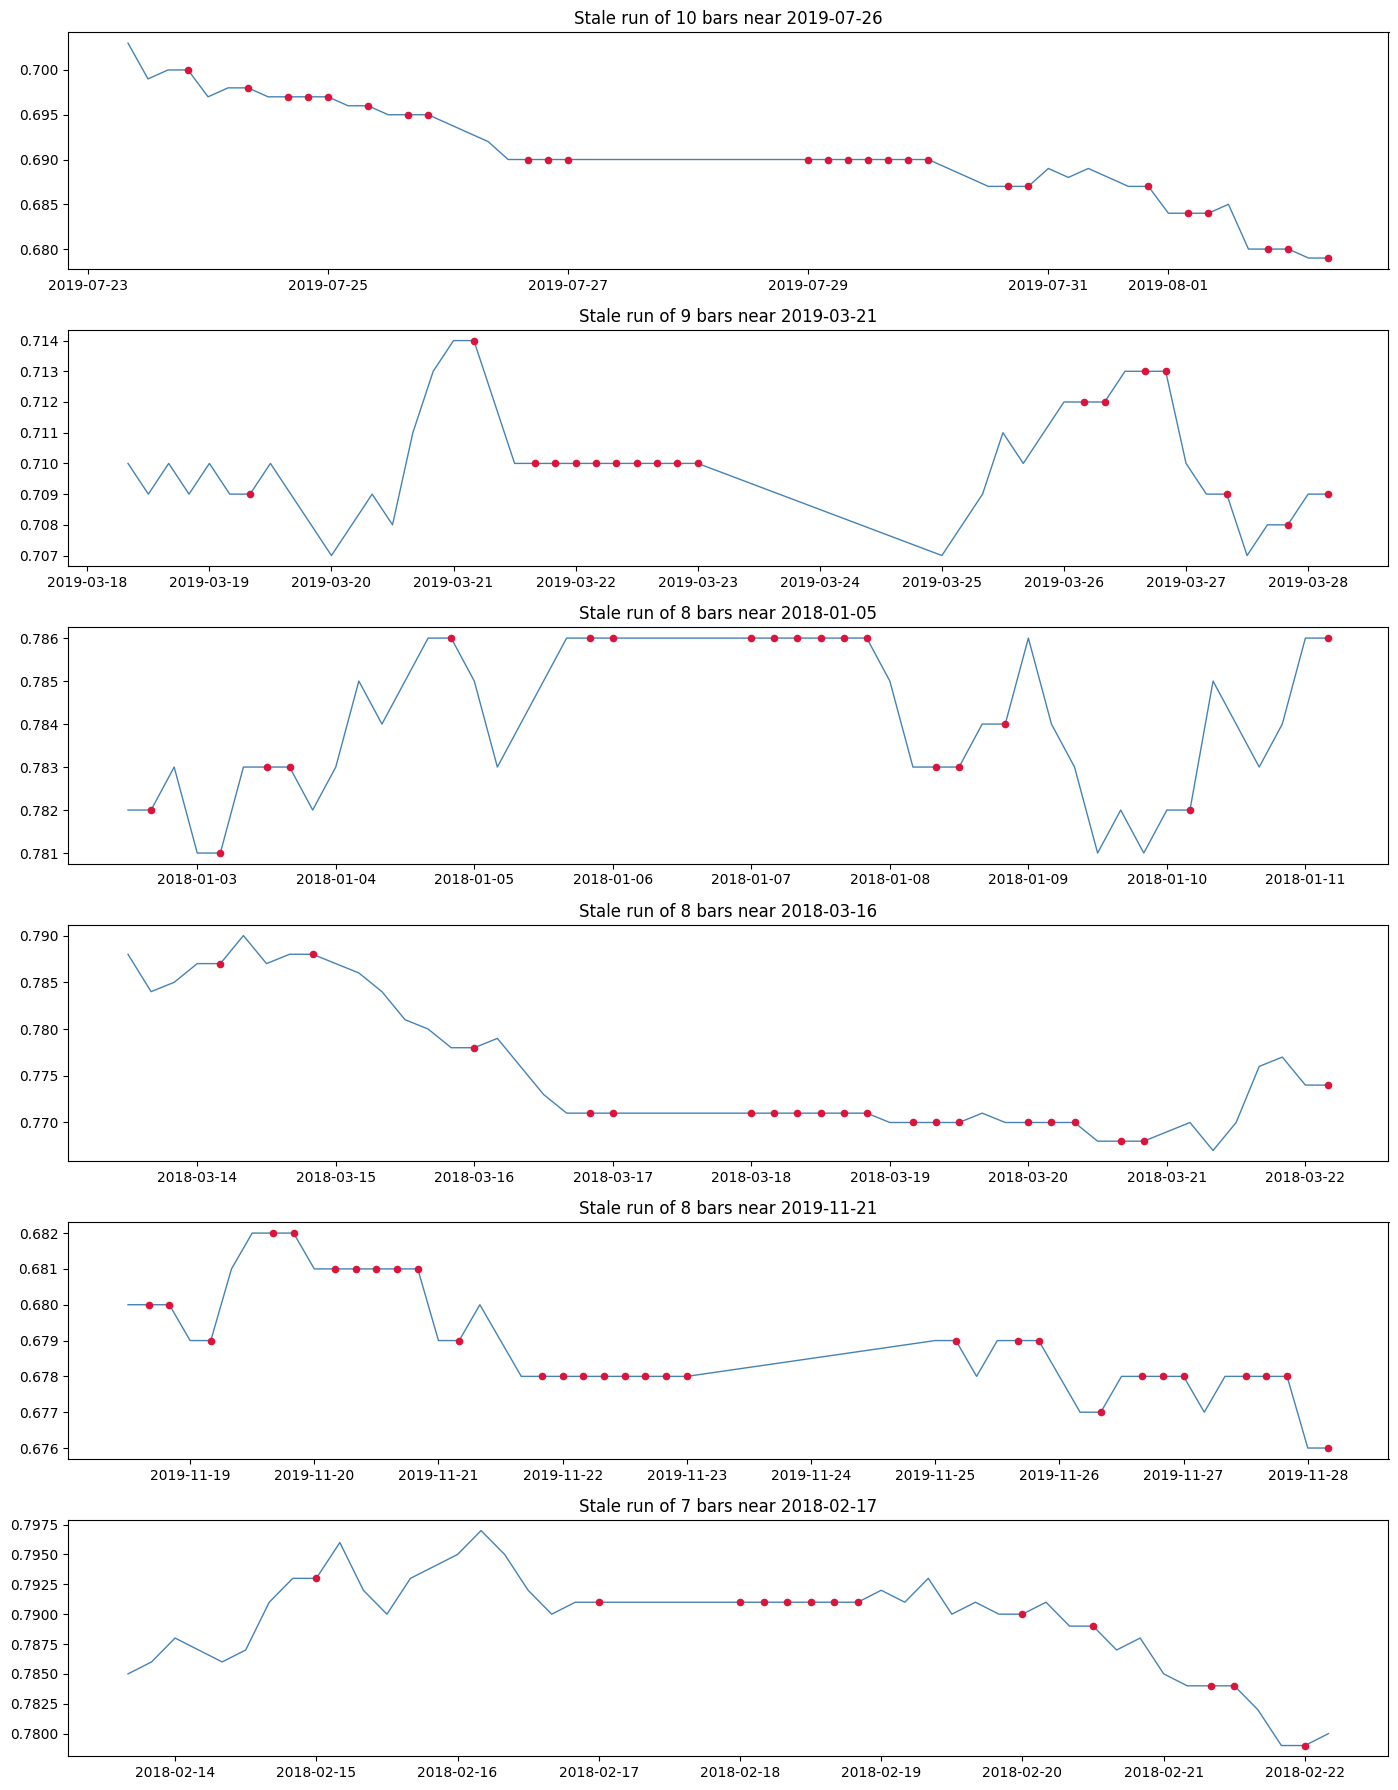

EUR/USD: 31 stale runs >= 5 bars
Longest run: 15 bars


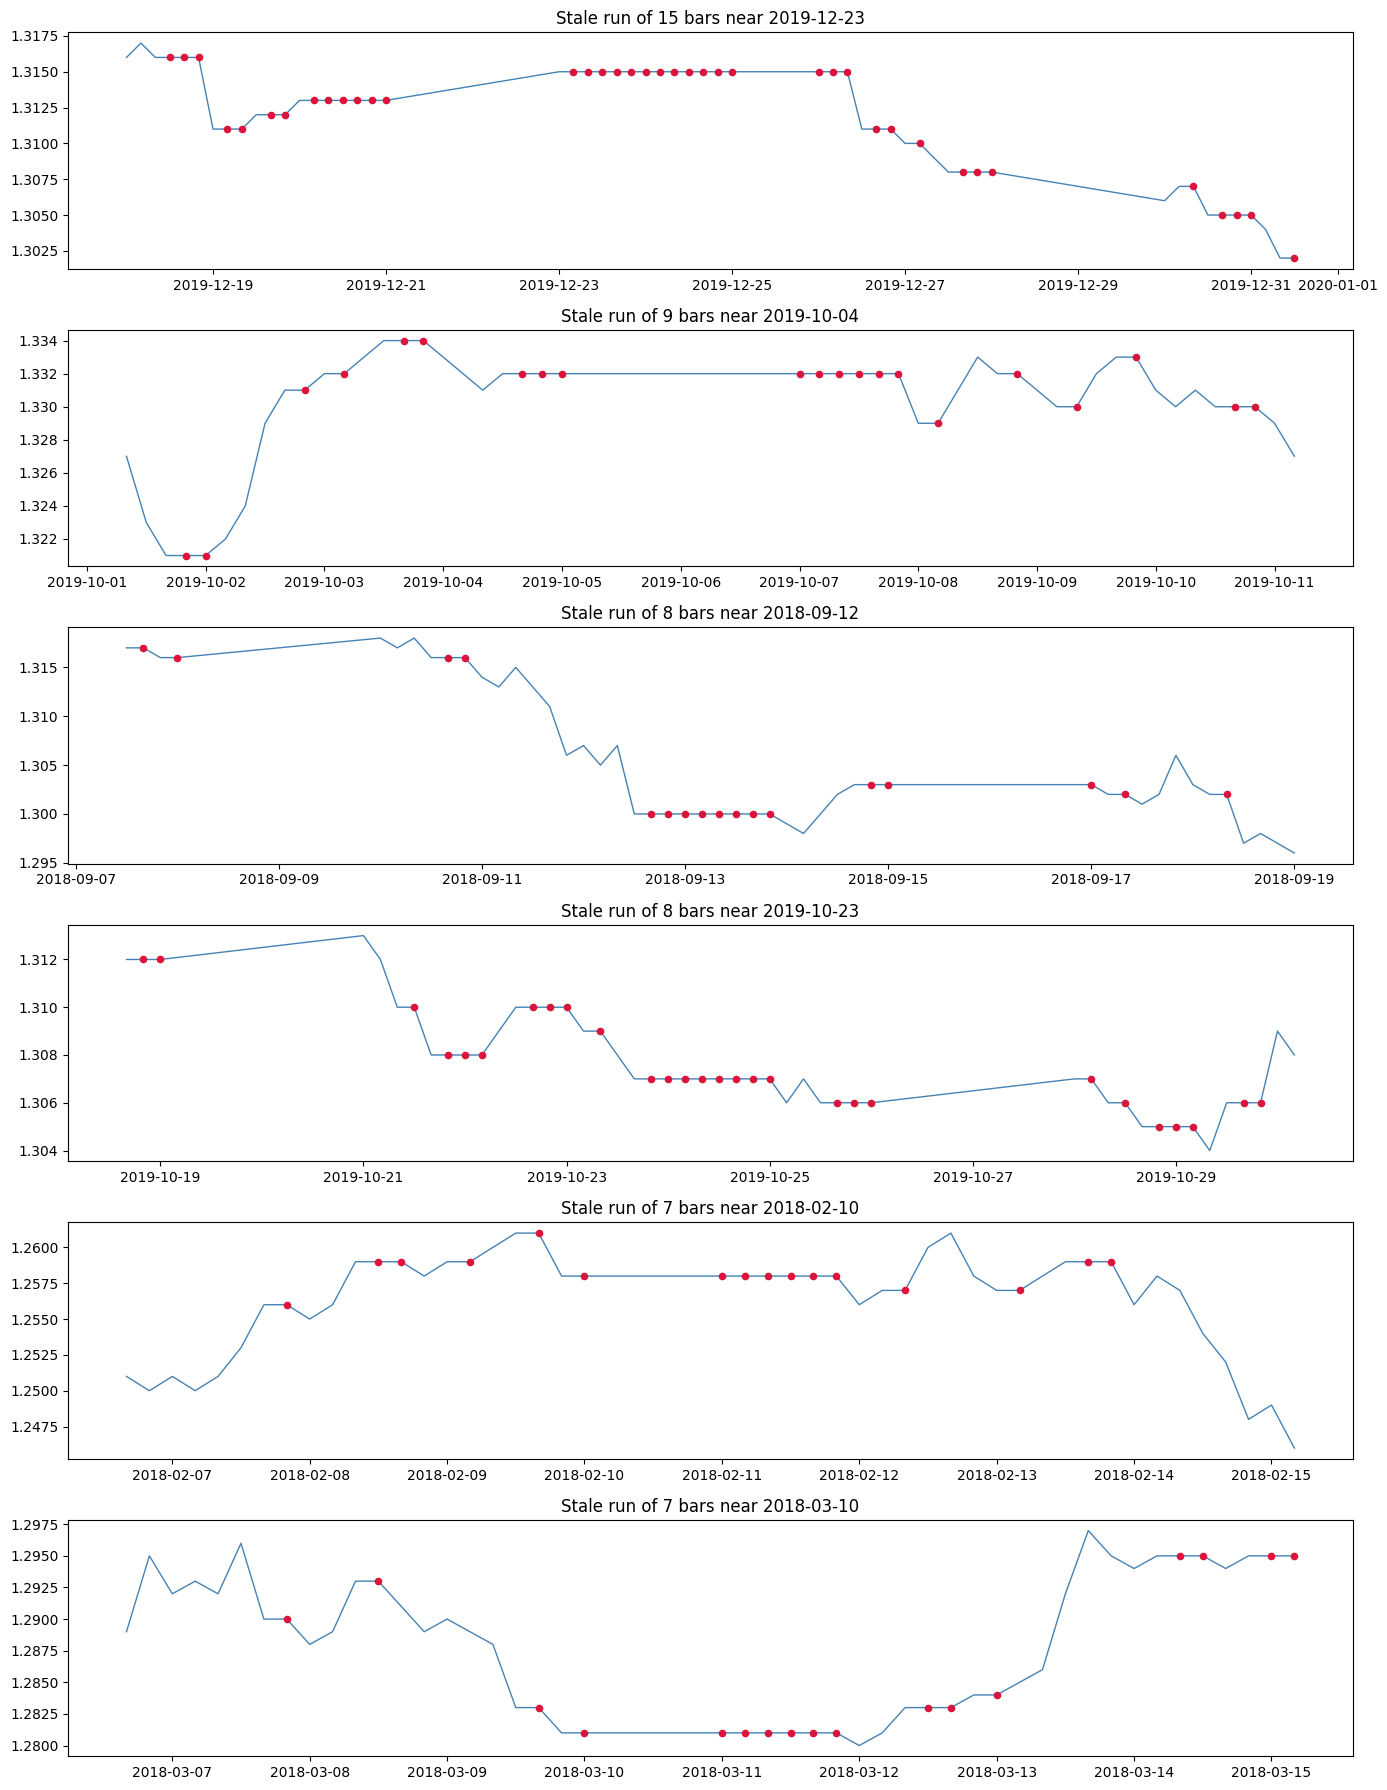

In [15]:
def investigate_stale_runs(df, pair_name="FX Pair", min_run=5):
    """
    Find and plot stale close price runs.
    
    Weekend bars are not present in the dataset because FX markets do not
    trade on weekends -- this is expected and confirmed in the gap analysis.
    Any stale run flagged here therefore occurs entirely within active
    trading hours (Monday 00:00 to Friday 22:00 UTC), which is why runs
    of 5+ bars are suspicious and worth inspecting.
    """
    is_stale = df["close"].diff() == 0
    run_id    = (is_stale != is_stale.shift()).cumsum()
    runs      = is_stale.groupby(run_id).agg(["sum", "first", "last", "idxmax"])
    long_runs = runs[(runs["sum"] >= min_run) & (runs["first"] == True)]

    print(f"{pair_name}: {len(long_runs)} stale runs >= {min_run} bars")
    print(f"Longest run: {long_runs['sum'].max()} bars")

    # Plot the 6 longest runs with context window
    fig, axes = plt.subplots(min(6, len(long_runs)), 1,
                             figsize=(14, 3 * min(6, len(long_runs))))
    if len(long_runs) == 1:
        axes = [axes]

    top_runs = long_runs.nlargest(6, "sum")
    for ax, (_, run) in zip(axes, top_runs.iterrows()):
        center = run["idxmax"]
        idx    = df.index.get_loc(center)
        window = df.iloc[max(0, idx - 20) : idx + int(run["sum"]) + 20]
        ax.plot(window.index, window["close"], color="steelblue", linewidth=1)
        stale_window = window[window["close"].diff() == 0]
        ax.scatter(stale_window.index, stale_window["close"],
                   color="crimson", s=20, zorder=5)
        ax.set_title(f"Stale run of {int(run['sum'])} bars near {center.date()}")

    plt.tight_layout()
    plt.show()

    return long_runs

stale_aud = investigate_stale_runs(df_4h_audusd, "AUD/USD")
stale_eur = investigate_stale_runs(df_4h_eurusd, "EUR/USD")

####  Decision: What to Actually Fix

In [16]:
def apply_all_fixes(df, pair_name, single_bar_spikes, max_interpolate_run=3):
    """
    Apply all fixes derived from investigation findings.

    Fix 1  - OHLC: enforce high=max(o,h,l,c), low=min(o,h,l,c)
    Fix 2  - Outliers: drop confirmed single-bar spike rows
    Fix 3  - Stale runs: interpolate short runs, NaN-out long runs
    Fix 4  - Gaps: no action (weekends + market holidays)
    Fix 5  - Volume spikes: no action (flag in commentary)
    """
    df = df.copy()
    print(f"  APPLYING FIXES: {pair_name}")
    print(f"{'-'*55}")

    # Fix 1: OHLC consistency
    # Not floating point -- use max/min enforcement only
    ohlc_cols = ["open", "high", "low", "close"]
    violations_before = (
        (df["high"] < df["low"])   |
        (df["high"] < df["open"])  |
        (df["high"] < df["close"]) |
        (df["low"]  > df["open"])  |
        (df["low"]  > df["close"])
    ).sum()

    df["high"] = df[ohlc_cols].max(axis=1)
    df["low"]  = df[ohlc_cols].min(axis=1)

    violations_after = (
        (df["high"] < df["low"])   |
        (df["high"] < df["open"])  |
        (df["high"] < df["close"]) |
        (df["low"]  > df["open"])  |
        (df["low"]  > df["close"])
    ).sum()
    print(f"\n[Fix 1] OHLC consistency")
    print(f"        Violations before : {violations_before}")
    print(f"        Violations after  : {violations_after}")


    # Fix 2: Drop confirmed single-bar data-error spikes
    # Keep genuine macro outliers (e.g. AUD/USD March 2020 crash)
    before = len(df)
    df = df.drop(index=single_bar_spikes.index, errors="ignore")
    print(f"\n[Fix 2] Single-bar spike removal")
    print(f"        Rows dropped      : {before - len(df)}")
    print(f"        Kept as macro     : outliers not in spike list")


    # Fix 3: Stale close price runs
    # Short runs (<= max_interpolate_run bars): time-interpolate
    # Long runs (> max_interpolate_run bars): set to NaN, forward-fill
    # as a last resort -- flag these bars with a boolean column
    df["stale_flag"] = False
    is_stale = df["close"].diff() == 0
    run_id   = (is_stale != is_stale.shift()).cumsum()

    # Label each bar with its run length
    run_lengths = is_stale.groupby(run_id).transform("sum")

    # Mark long stale bars before touching the data
    long_stale_mask = is_stale & (run_lengths > max_interpolate_run)
    df.loc[long_stale_mask, "stale_flag"] = True

    # NaN out all stale close values then interpolate
    df.loc[is_stale, "close"] = np.nan

    # Time-based interpolation (respects uneven gaps after spike drops)
    df["close"] = df["close"].interpolate(method="time", limit=max_interpolate_run)

    # Any remaining NaN (long runs beyond interpolation limit): forward-fill
    remaining_nan = df["close"].isna().sum()
    if remaining_nan > 0:
        df["close"] = df["close"].ffill()
        print(f"\n[Fix 3] Stale run treatment")
        print(f"        Short runs interpolated")
        print(f"        Long runs forward-filled ({remaining_nan} bars) -- stale_flag=True")
    else:
        print(f"\n[Fix 3] Stale run treatment")
        print(f"        All stale runs resolved by interpolation")

    stale_flagged = df["stale_flag"].sum()
    print(f"        Bars flagged as long-stale: {stale_flagged}")


    # Summary
    print(f"\n[Summary]")
    print(f"        Rows before fixes : {before}")
    print(f"        Rows after fixes  : {len(df)}")
    print(f"        Stale flags set   : {stale_flagged}")
    print(f"        Remaining NaN     : {df.isnull().sum().sum()}")

    return df


# Apply
df_4h_audusd_clean = apply_all_fixes(
    df_4h_audusd,
    pair_name="AUD/USD",
    single_bar_spikes=spikes_aud,
    max_interpolate_run=3
)

df_4h_eurusd_clean = apply_all_fixes(
    df_4h_eurusd,
    pair_name="EUR/USD",
    single_bar_spikes=spikes_eur,
    max_interpolate_run=3
)

  APPLYING FIXES: AUD/USD
-------------------------------------------------------

[Fix 1] OHLC consistency
        Violations before : 0
        Violations after  : 0

[Fix 2] Single-bar spike removal
        Rows dropped      : 2
        Kept as macro     : outliers not in spike list

[Fix 3] Stale run treatment
        Short runs interpolated
        Long runs forward-filled (172 bars) -- stale_flag=True
        Bars flagged as long-stale: 436

[Summary]
        Rows before fixes : 4861
        Rows after fixes  : 4859
        Stale flags set   : 436
        Remaining NaN     : 0
  APPLYING FIXES: EUR/USD
-------------------------------------------------------

[Fix 1] OHLC consistency
        Violations before : 0
        Violations after  : 0

[Fix 2] Single-bar spike removal
        Rows dropped      : 4
        Kept as macro     : outliers not in spike list

[Fix 3] Stale run treatment
        Short runs interpolated
        Long runs forward-filled (134 bars) -- stale_flag=True

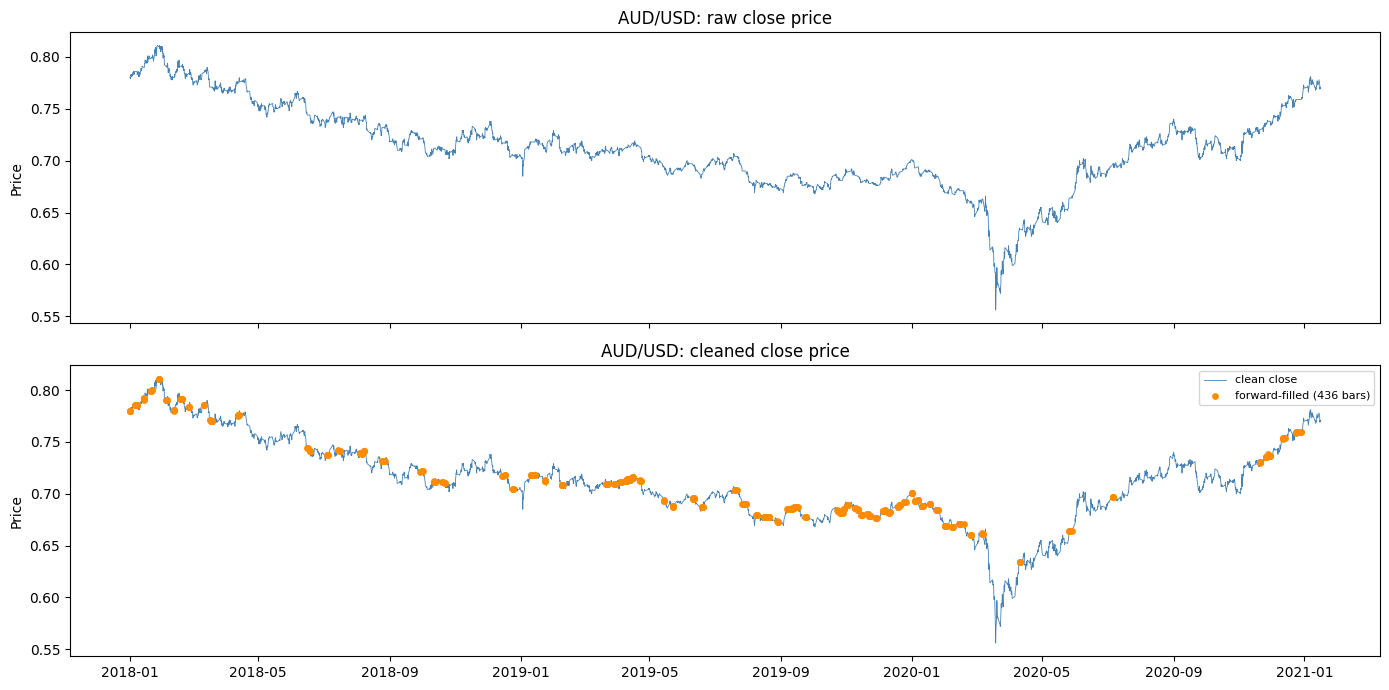

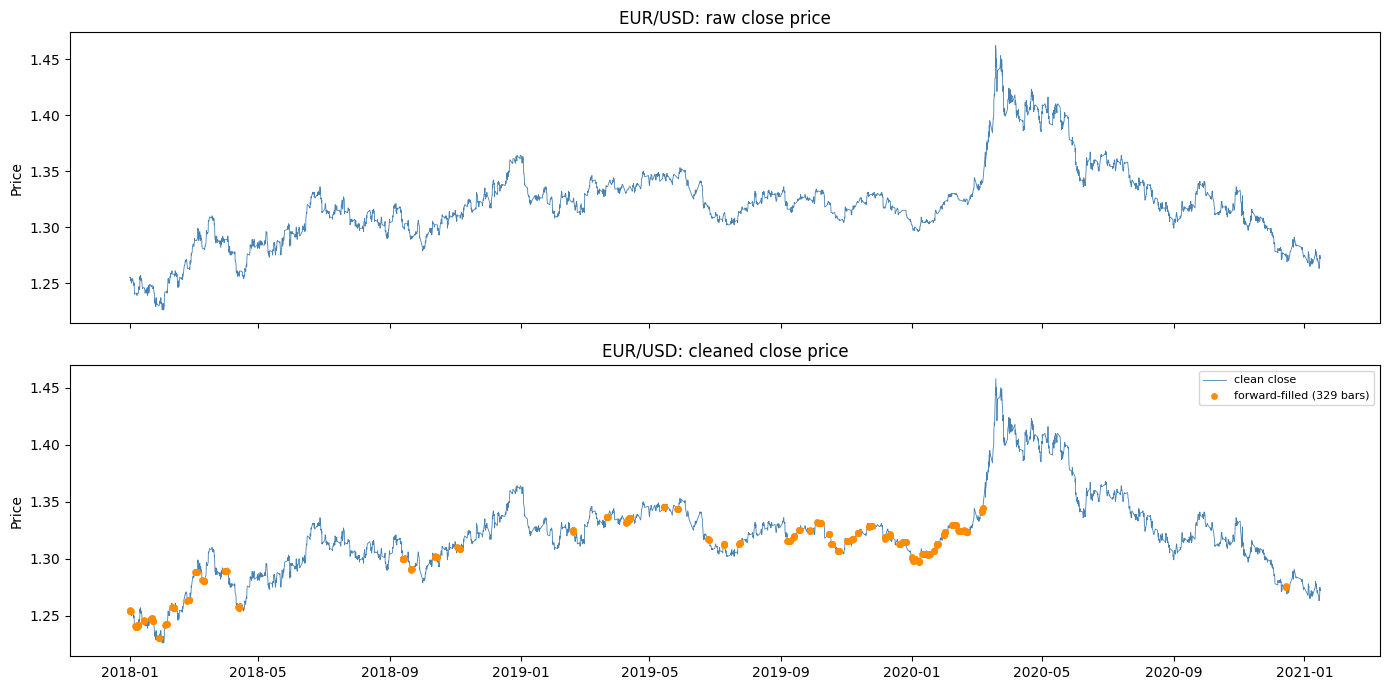

In [17]:
def plot_fix_comparison(df_raw, df_clean, pair_name):
    """
    Side-by-side close price: raw vs cleaned.
    Stale-flagged bars highlighted so you can see what was touched.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(df_raw.index, df_raw["close"],
                 color="steelblue", linewidth=0.6)
    axes[0].set_title(f"{pair_name}: raw close price")
    axes[0].set_ylabel("Price")

    axes[1].plot(df_clean.index, df_clean["close"],
                 color="steelblue", linewidth=0.6, label="clean close")
    if "stale_flag" in df_clean.columns:
        flagged = df_clean[df_clean["stale_flag"]]
        axes[1].scatter(flagged.index, flagged["close"],
                        color="darkorange", s=15, zorder=5,
                        label=f"forward-filled ({len(flagged)} bars)")
    axes[1].set_title(f"{pair_name}: cleaned close price")
    axes[1].set_ylabel("Price")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_fix_comparison(df_4h_audusd, df_4h_audusd_clean, "AUD/USD")
plot_fix_comparison(df_4h_eurusd, df_4h_eurusd_clean, "EUR/USD")

#### Export clean Datasets

In [43]:
save_path = r"C:\Users\Hassa\OneDrive - Loughborough University\current\Algorithmic Trading for Beginners\FTSA\TSACapstoneTemplate\TSACapstoneTemplate\data_modules"

df_4h_audusd_clean.to_pickle(os.path.join(save_path, "fx_pair_1_4h_clean.pkl"))
df_4h_eurusd_clean.to_pickle(os.path.join(save_path, "fx_pair_2_4h_clean.pkl"))

print(f"Saved AUD/USD: {df_4h_audusd_clean.shape}")
print(f"Saved EUR/USD: {df_4h_eurusd_clean.shape}")

Saved AUD/USD: (4859, 6)
Saved EUR/USD: (4857, 6)
